In [1]:
!pip install optuna

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import math
import gc
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error,
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [3]:
df = pd.read_csv("China_Rainfall_43y.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124589 entries, 0 to 124588
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   date       124589 non-null  object 
 1   adm_level  124589 non-null  int64  
 2   adm_id     124589 non-null  int64  
 3   PCODE      124589 non-null  int64  
 4   n_pixels   124589 non-null  float64
 5   rfh        124589 non-null  float64
 6   rfh_avg    124589 non-null  float64
 7   r1h        124589 non-null  float64
 8   r1h_avg    124589 non-null  float64
 9   r3h        124589 non-null  float64
 10  r3h_avg    124589 non-null  float64
 11  rfq        124589 non-null  float64
 12  r1q        124589 non-null  float64
 13  r3q        124589 non-null  float64
 14  version    124589 non-null  object 
 15  month      124589 non-null  int64  
 16  dekad      124589 non-null  int64  
dtypes: float64(10), int64(5), object(2)
memory usage: 16.2+ MB


In [4]:
len(df["PCODE"].unique())

81

In [5]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

df = df.drop(['date', 'adm_level', 'adm_id', 'version', 'n_pixels'], axis=1 )
df = df.sort_values(['PCODE','year','month','dekad']).reset_index(drop=True)
df.columns

Index(['PCODE', 'rfh', 'rfh_avg', 'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq',
       'r1q', 'r3q', 'month', 'dekad', 'year'],
      dtype='object')

In [6]:
DROP_COLS = [
    'rfq','r1q','r3q','rfh_avg','r1h_avg','r3h_avg',
    'n_pixels','version','Unnamed: 0','adm_id','adm_level',
]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
df = df.sort_values(['PCODE','year','month','dekad']).reset_index(drop=True)
print(f'Raw shape: {df.shape}')
df.head(10)

Raw shape: (124589, 7)


,PCODE,rfh,r1h,r3h,month,dekad,year
0,0,1.569444,5.572917,24.118055,1,1,1982
1,0,1.104167,4.951389,19.357640,1,11,1982
2,0,1.614583,4.288195,18.534723,1,21,1982
3,0,0.993056,3.711806,14.465278,2,1,1982
4,0,1.083333,3.690972,14.416666,2,11,1982
5,0,1.437500,3.513889,13.048611,2,21,1982
6,0,1.854167,4.375000,13.659722,3,1,1982
7,0,2.638889,5.930555,14.572916,3,11,1982
8,0,1.857639,6.350694,14.152779,3,21,1982
9,0,2.250000,6.746528,14.833334,4,1,1982


In [7]:
# Lag features
for lag in [1, 2, 3, 6, 12]:
    df[f'rfh_lag_{lag}'] = df.groupby('PCODE')['rfh'].shift(lag)
df = df.dropna().reset_index(drop=True)

# Encode PCODE
df['PCODE'] = df['PCODE'].astype('category').cat.codes
NUM_PCODES  = df['PCODE'].nunique()

# Cyclic time features
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dekad_sin'] = np.sin(2 * np.pi * df['dekad'] / 3)
df['dekad_cos'] = np.cos(2 * np.pi * df['dekad'] / 3)

print(f'df: {df.shape}, PCODEs: {NUM_PCODES}')
df.head()

df: (123617, 16), PCODEs: 81


,PCODE,rfh,r1h,r3h,month,dekad,year,rfh_lag_1,rfh_lag_2,rfh_lag_3,rfh_lag_6,rfh_lag_12,month_sin,month_cos,dekad_sin,dekad_cos
0,0,12.204861,20.541666,31.663193,5,1,1982,5.534722,2.802083,2.250000,1.854167,1.569444,5.000000e-01,-0.866025,8.660254e-01,-0.5
1,0,10.163195,27.902777,40.743057,5,11,1982,12.204861,5.534722,2.802083,2.638889,1.104167,5.000000e-01,-0.866025,-8.660254e-01,-0.5
2,0,11.937500,34.305557,51.243057,5,21,1982,10.163195,12.204861,5.534722,1.857639,1.614583,5.000000e-01,-0.866025,-1.714506e-15,1.0
3,0,7.368055,29.468750,56.756943,6,1,1982,11.937500,10.163195,12.204861,2.250000,0.993056,1.224647e-16,-1.000000,8.660254e-01,-0.5
4,0,66.368060,85.673615,120.486115,6,11,1982,7.368055,11.937500,10.163195,2.802083,1.083333,1.224647e-16,-1.000000,-8.660254e-01,-0.5


In [8]:
train_df = df[df['year'] <= 2015]
val_df = df[(df['year'] > 2015) & (df['year'] <= 2020)]
test_df = df[df['year'] > 2020]

print("train:",(train_df.shape))
print("val:",(val_df.shape))
print("test:",(test_df.shape))

train: (95494, 16)
val: (14083, 16)
test: (14040, 16)


In [9]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

In [10]:
transform_cols = [
    'rfh', 'r1h', 'r3h',
    'rfh_lag_1', 'rfh_lag_2','rfh_lag_3', 'rfh_lag_6','rfh_lag_12'
]
# Apply Yeo–Johnson
pt = PowerTransformer(method='yeo-johnson')

train_df[transform_cols] = pt.fit_transform(train_df[transform_cols])
val_df[transform_cols] = pt.transform(val_df[transform_cols])
test_df[transform_cols] = pt.transform(test_df[transform_cols])

# Apply RobustScaler
scaler = RobustScaler()

train_df[transform_cols] = scaler.fit_transform(train_df[transform_cols])
val_df[transform_cols] = scaler.transform(val_df[transform_cols])
test_df[transform_cols] = scaler.transform(test_df[transform_cols])

In [11]:
FEATURES = [
    'rfh','r1h','r3h',
    'rfh_lag_1','rfh_lag_2','rfh_lag_3','rfh_lag_6','rfh_lag_12',
    'month_sin','month_cos','dekad_sin','dekad_cos',
    'month','dekad',
]
TARGET    = 'rfh'
SEQ_LEN   = 24
NUM_FEATS = len(FEATURES)
print(f'Features: {NUM_FEATS} , Sequence length: {SEQ_LEN}')

Features: 14 , Sequence length: 24


In [12]:
X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values

X_val = val_df[FEATURES].values
y_val = val_df[TARGET].values

X_test = test_df[FEATURES].values
y_test = test_df[TARGET].values

X_train = X_train.astype('float32')
y_train = y_train.astype('float32')
X_val = X_val.astype('float32')
y_val = y_val.astype('float32')
X_test = X_test.astype('float32')
y_test = y_test.astype('float32')

X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)
X_val = torch.tensor(X_val)
y_val = torch.tensor(y_val)
X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test)

In [13]:
def create_sequences_per_pcode(df, features, target, seq_len=24):
    X_list, y_list, pcode_list = [], [], []

    for pcode, group in df.groupby('PCODE'):
        group = group.sort_values(['year','month','dekad'])

        X = group[features].values
        y = group[target].values

        for i in range(len(group) - seq_len):
            X_list.append(X[i:i+seq_len])
            y_list.append(y[i+seq_len])
            pcode_list.append(pcode)

    return (
        torch.tensor(X_list, dtype=torch.float32),
        torch.tensor(y_list, dtype=torch.float32),
        torch.tensor(pcode_list, dtype=torch.long)
    )

In [14]:
X_train, y_train, p_train = create_sequences_per_pcode(train_df, FEATURES, TARGET, seq_len=24)
X_val, y_val, p_val       = create_sequences_per_pcode(val_df, FEATURES, TARGET, seq_len=24)
X_test, y_test, p_test    = create_sequences_per_pcode(test_df, FEATURES, TARGET, seq_len=24)

/tmp/ipykernel_20268/3299349123.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.tensor(X_list, dtype=torch.float32),


In [15]:
train_ds = TensorDataset(X_train, y_train, p_train)
val_ds   = TensorDataset(X_val, y_val, p_val)
test_ds  = TensorDataset(X_test, y_test, p_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, pin_memory=True)

In [16]:
class iTransformer(nn.Module):
    def __init__(self, num_features, seq_len, num_pcodes, d_model=128, n_heads=4, num_layers=3, d_ff=256, dropout=0.1, pcode_embed_dim=16):
        super().__init__()

        # 1. PCODE embedding
        self.pcode_emb = nn.Embedding(num_pcodes, pcode_embed_dim)
        # 2. Inverted embedding (Time → Representation)
        self.value_embedding = nn.Linear(seq_len, d_model)
        # 3. Feature (token) embedding
        self.feature_embedding = nn.Parameter(torch.randn(1, num_features, d_model))
        # 4. Combine dim
        self.total_dim = d_model + pcode_embed_dim

        # 5. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.total_dim,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        # 6. LayerNorm
        self.norm = nn.LayerNorm(self.total_dim)

        # 7. Prediction head
        self.head = nn.Sequential(
            nn.Linear(self.total_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, pcode):
        # x: (B, T, F)

        B, T, F = x.shape

        # 1. Invert → (B, F, T)
        x = x.permute(0, 2, 1)

        # 2. Project time → representation
        x = self.value_embedding(x)  # (B, F, d_model)

        # 3. Add feature embedding (VERY IMPORTANT - paper detail)
        x = x + self.feature_embedding

        # 4. PCODE embedding
        p_emb = self.pcode_emb(pcode)  # (B, E)
        p_emb = p_emb.unsqueeze(1).expand(-1, F, -1)

        # 5. Concatenate
        x = torch.cat([x, p_emb], dim=-1)

        # 6. Normalize
        x = self.norm(x)

        # 7. Transformer (attention across FEATURES)
        x = self.encoder(x)

        # 8. Aggregation (mean over features)
        x = x.mean(dim=1)

        # 9. Prediction
        out = self.head(x)

        return out.squeeze()

In [17]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for X, y, p in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        p = p.to(device, non_blocking=True)

        optimizer.zero_grad()
        out = model(X, p)
        loss = criterion(out, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0


    with torch.no_grad():
        for X, y, p in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            p = p.to(device, non_blocking=True)

            out = model(X, p)
            loss = criterion(out, y)

            total_loss += loss.item()

    return total_loss / len(loader)

In [18]:
def objective(trial):

    # Search space (paper-style)
    d_model = trial.suggest_categorical("d_model", [64, 128, 256])
    n_heads = trial.suggest_categorical("n_heads", [2, 4, 8])
    num_layers = trial.suggest_int("num_layers", 2, 4)
    d_ff = trial.suggest_categorical("d_ff", [128, 256, 512])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    pcode_embed_dim = trial.suggest_categorical("pcode_embed_dim", [8, 16, 32])
    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    # Model
    model = iTransformer(
        num_features=14,
        seq_len=24,
        num_pcodes=81,
        d_model=d_model,
        n_heads=n_heads,
        num_layers=num_layers,
        d_ff=d_ff,
        dropout=dropout,
        pcode_embed_dim=pcode_embed_dim
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_val = float("inf")
    patience = 5
    patience_counter = 0

    # Training loop
    for epoch in range(20):

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss   = validate(model, val_loader, criterion)

        trial.report(val_loss, epoch)

        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

        # Pruning (Optuna magic )
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val

In [19]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=20)

print("Best Trial:")
print(study.best_trial.params)

Best Trial:
{'d_model': 64, 'n_heads': 4, 'num_layers': 4, 'd_ff': 256, 'dropout': 0.187656623063352, 'pcode_embed_dim': 32, 'lr': 0.00016742003629756442, 'weight_decay': 8.10081951130693e-05}


In [20]:
best_params = study.best_trial.params

model = iTransformer(
    num_features=14,
    seq_len=24,
    num_pcodes=81,
    d_model=best_params["d_model"],
    n_heads=best_params["n_heads"],
    num_layers=best_params["num_layers"],
    d_ff=best_params["d_ff"],
    dropout=best_params["dropout"],
    pcode_embed_dim=best_params["pcode_embed_dim"]
).to(device)

optimizer = torch.optim.AdamW( model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])

criterion = nn.MSELoss()

In [21]:
best_val = float("inf")

for epoch in range(50):

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss   = validate(model, val_loader, criterion)

    print(f"Epoch {epoch+1} | Train {train_loss:.4f} | Val {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "china_itransformer.pth")

Epoch 1 | Train 0.2108 | Val 0.1708
Epoch 2 | Train 0.1756 | Val 0.1611
Epoch 3 | Train 0.1697 | Val 0.1625
Epoch 4 | Train 0.1655 | Val 0.1611
Epoch 5 | Train 0.1635 | Val 0.1632
Epoch 6 | Train 0.1617 | Val 0.1593
Epoch 7 | Train 0.1602 | Val 0.1610
Epoch 8 | Train 0.1588 | Val 0.1642
Epoch 9 | Train 0.1574 | Val 0.1641
Epoch 10 | Train 0.1565 | Val 0.1603
Epoch 11 | Train 0.1551 | Val 0.1643
Epoch 12 | Train 0.1541 | Val 0.1663
Epoch 13 | Train 0.1531 | Val 0.1618
Epoch 14 | Train 0.1519 | Val 0.1685
Epoch 15 | Train 0.1505 | Val 0.1755
Epoch 16 | Train 0.1496 | Val 0.1651
Epoch 17 | Train 0.1485 | Val 0.1680
Epoch 18 | Train 0.1469 | Val 0.1695
Epoch 19 | Train 0.1455 | Val 0.1774
Epoch 20 | Train 0.1442 | Val 0.1728
Epoch 21 | Train 0.1430 | Val 0.1744
Epoch 22 | Train 0.1411 | Val 0.1739
Epoch 23 | Train 0.1394 | Val 0.1765
Epoch 24 | Train 0.1376 | Val 0.1845
Epoch 25 | Train 0.1362 | Val 0.1799
Epoch 26 | Train 0.1345 | Val 0.1799
Epoch 27 | Train 0.1325 | Val 0.1940
Epoch 28 |

In [22]:
model.load_state_dict(torch.load("china_itransformer.pth"))
model.eval()

preds, actuals = [], []

with torch.no_grad():
    for X, y, p in test_loader:
        X = X.to(device)
        p = p.to(device)

        out = model(X, p)

        preds.append(out.cpu().numpy())
        actuals.append(y.numpy())

preds = np.concatenate(preds).reshape(-1, 1)
actuals = np.concatenate(actuals).reshape(-1, 1)



preds = preds.flatten()
actuals = actuals.flatten()

In [23]:
rmse = np.sqrt(mean_squared_error( actuals, preds))
mae  = mean_absolute_error(actuals, preds)
r2   = r2_score(actuals, preds)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

RMSE: 0.39968965158487374
MAE : 0.31714558601379395
R2  : 0.6314874887466431


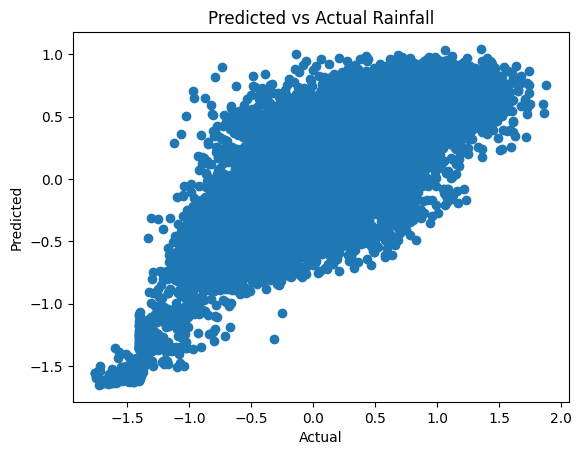

In [24]:
plt.figure()
plt.scatter(actuals, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Rainfall")
plt.show()